In [14]:
# Bibliotecas 

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

### 1. Generar una señal de ECG

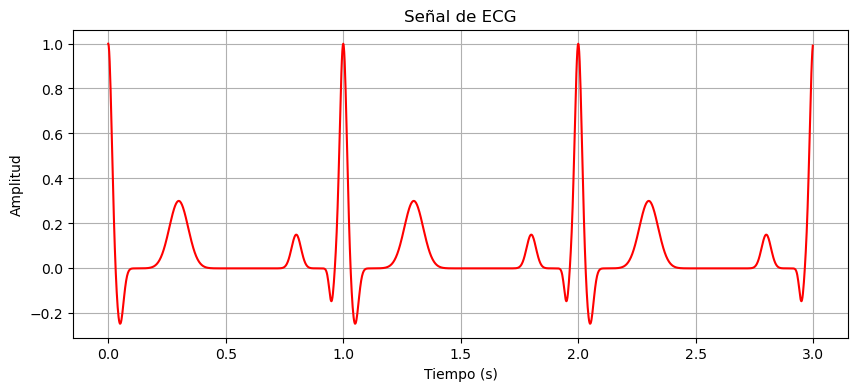

In [23]:
frecuencia = 500  # Frecuencia de muestreo (500 Hz)
t = np.arange(0, 3, 1/frecuencia)  # Vector de tiempo de 3 segundos

# Utilizamos funciones Gaussianas para simular el PQRST
def simular_latido(t_local):
    ondas = [
        (0.15, -0.2, 0.02),   # Onda P
        (-0.15, -0.05, 0.01), # Onda Q
        (1.0, 0.0, 0.015),    # Onda R
        (-0.25, 0.05, 0.015), # Onda S
        (0.3, 0.3, 0.04)      # Onda T
    ]

    latido = np.zeros_like(t_local)
    
    for a, mu, sigma in ondas:
    
        latido += a * np.exp(-0.5 * ((t_local - mu) / sigma)**2)
    
    return latido

# Creamos una señal vacía y le sumamos latidos cada 1 segundo
ecg_original = np.zeros_like(t)

for i in range(4):

    ecg_original += simular_latido(t - i)

plt.figure(figsize = (10, 4))
plt.plot(t, ecg_original, color = 'red')
plt.title('Señal de ECG')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

### 2. Añadir ruido de alta frecuencia y ruido aleatorio

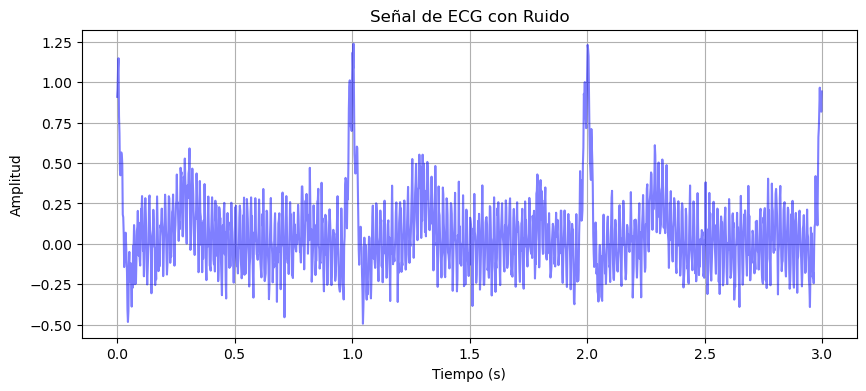

In [22]:
ruido_60hz = 0.2 * np.sin(2 * np.pi * 60 * t)
ruido_gauss = np.random.normal(0, 0.08, len(t))

ecg_ruidoso = ecg_original + ruido_60hz + ruido_gauss

plt.figure(figsize = (10, 4))
plt.plot(t, ecg_ruidoso, color = 'blue', alpha = 0.5)
plt.title('Señal de ECG con Ruido')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

### 3. Analizar el espectro de frecuencia con la transformada de $\mathcal{F}\text{ourier}$

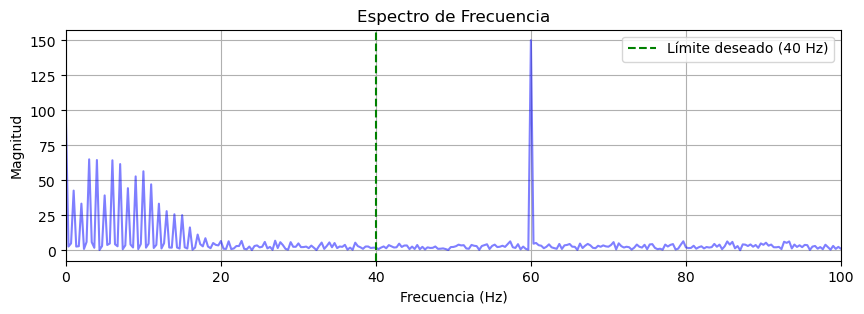

In [ ]:
N = len(t)
freqs = np.fft.fftfreq(N, 1/frecuencia)
fft_ruidoso = np.fft.fft(ecg_ruidoso)

plt.figure(figsize = (10, 3))
plt.plot(freqs[:N//2], np.abs(fft_ruidoso)[:N//2], color = 'blue', alpha = 0.5)
plt.title('Espectro de Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, 100)
plt.axvline(40, color = 'green', linestyle = '--', label = 'Límite deseado (40 Hz)')

plt.legend()
plt.grid(True)
plt.show()

### 4. Diseñar un filtro en el dominio de la frecuencia.

In [30]:
fft_filtrado = fft_ruidoso.copy()
fft_filtrado[np.abs(freqs) > 40] = 0  

# Transformada inversa (IFFT) para volver al dominio del tiempo
ecg_filtrado_freq = np.real(np.fft.ifft(fft_filtrado))

### 6. Diseñar un filtro en el dominio del tiempo.

In [40]:
# Filtro Butterworth pasa bajas
b, a = butter(4, 40, fs = frecuencia, btype = 'low')

ecg_filtrado_tiempo = filtfilt(b, a, ecg_ruidoso)

### 5. Comparar la señal original, con ruido y filtrada, superponer y comentar.

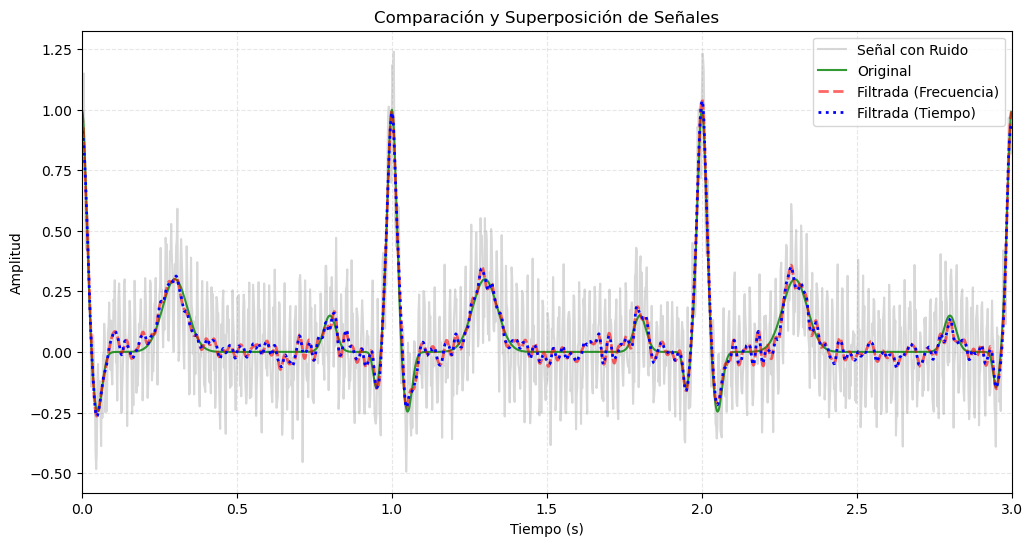

In [46]:
plt.figure(figsize = (12, 6))

plt.plot(t, ecg_ruidoso, label = 'Señal con Ruido', color = 'gray', alpha = 0.3)
plt.plot(t, ecg_original, label = 'Original', color = 'green', linewidth = 1.5, alpha = 0.8)
plt.plot(t, ecg_filtrado_freq, label = 'Filtrada (Frecuencia)', color = 'red', linestyle = 'dashed', linewidth = 2, alpha = 0.6)
plt.plot(t, ecg_filtrado_tiempo, label = 'Filtrada (Tiempo)', color = 'blue', linestyle = 'dotted', linewidth = 2)

plt.title('Comparación y Superposición de Señales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.xlim(0, 3)
plt.legend(loc = 'upper right')
plt.grid(True, alpha = 0.3, linestyle = '--')
plt.show()